# Análisis Exploratorio de Datos (EDA) - Give Me Some Credit
## Predicción de Riesgo Crediticio

Este notebook presenta un análisis exhaustivo del dataset de Give Me Some Credit, el cual contiene información sobre clientes y su historial de pagos. El objetivo es identificar patrones y relaciones que ayuden a predecir si un cliente incurrirá en un atraso grave (90+ días) en los próximos 2 años.

## 1. Importación de Librerías y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 2. Carga de Datos

In [2]:
# Cargar el dataset de entrenamiento
import os
p = 'data/GiveMeSomeCredit/cs-training.csv'
if os.path.exists(p):
    df = pd.read_csv(p, index_col=0)
    print("Dataset cargado exitosamente")
    print(f"Tamaño del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
else:
    print(f'File not found: {p}. Skipping load.')
    df = pd.DataFrame()

Dataset cargado exitosamente
Tamaño del dataset: 150,000 filas × 11 columnas


## 3. Información General del Dataset

### 3.1 Estructura Básica
Exploración inicial de la estructura del dataset, tipos de datos y valores faltantes.

In [3]:
# Primeras filas del dataset
print("Primeras 5 filas del dataset:")
print(df.head())
print("\n" + "="*80 + "\n")

# Información de tipos de datos
print("Información del dataset:")
print(df.info())

Primeras 5 filas del dataset:
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
1                 1                              0.766127   45   
2                 0                              0.957151   40   
3                 0                              0.658180   38   
4                 0                              0.233810   30   
5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
1                                     2   0.802982         9120.0   
2                                     0   0.121876         2600.0   
3                                     1   0.085113         3042.0   
4                                     0   0.036050         3300.0   
5                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
1                               13                        0   
2                               

### 3.2 Análisis de Valores Faltantes

Identificación de datos faltantes por columna, crucial para decisiones de preprocesamiento.

Valores Faltantes por Variable:
          Variable  Valores Faltantes  Porcentaje (%)
     MonthlyIncome              29731           19.82
NumberOfDependents               3924            2.62


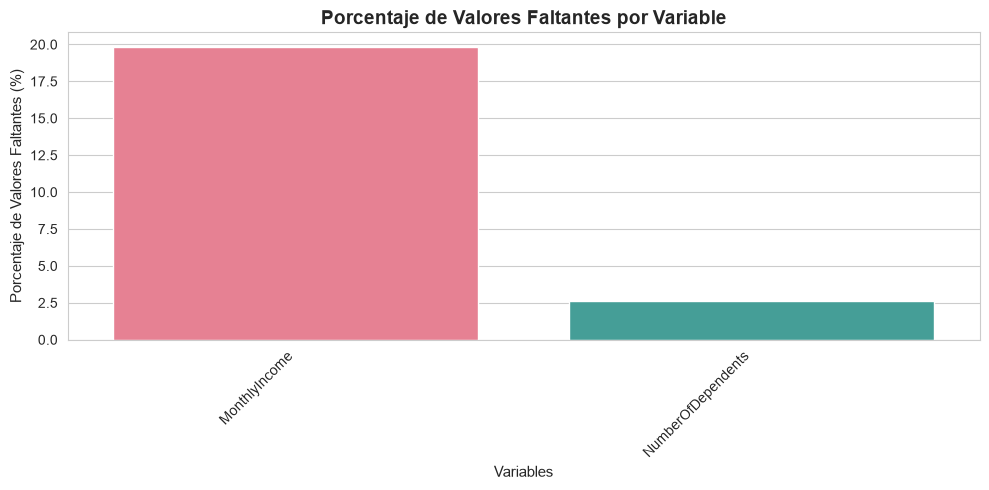

In [4]:
# Análisis de valores faltantes
missing_data = pd.DataFrame({
    'Variable': df.columns,
    'Valores Faltantes': df.isnull().sum().values,
    'Porcentaje (%)': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Valores Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)
print("Valores Faltantes por Variable:")
print(missing_data.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
if len(missing_data) > 0:
    sns.barplot(data=missing_data, x='Variable', y='Porcentaje (%)', palette='husl', ax=ax)
    ax.set_title('Porcentaje de Valores Faltantes por Variable', fontsize=14, fontweight='bold')
    ax.set_ylabel('Porcentaje de Valores Faltantes (%)', fontsize=11)
    ax.set_xlabel('Variables', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No hay valores faltantes en el dataset")

### 3.3 Estadísticas Descriptivas

Resumen estadístico de todas las variables numéricas.

In [5]:
# Estadísticas descriptivas
print("Estadísticas Descriptivas:")
print(df.describe().T.round(2))

Estadísticas Descriptivas:


                                         count     mean       std  min  \
SeriousDlqin2yrs                      150000.0     0.07      0.25  0.0   
RevolvingUtilizationOfUnsecuredLines  150000.0     6.05    249.76  0.0   
age                                   150000.0    52.30     14.77  0.0   
NumberOfTime30-59DaysPastDueNotWorse  150000.0     0.42      4.19  0.0   
DebtRatio                             150000.0   353.01   2037.82  0.0   
MonthlyIncome                         120269.0  6670.22  14384.67  0.0   
NumberOfOpenCreditLinesAndLoans       150000.0     8.45      5.15  0.0   
NumberOfTimes90DaysLate               150000.0     0.27      4.17  0.0   
NumberRealEstateLoansOrLines          150000.0     1.02      1.13  0.0   
NumberOfTime60-89DaysPastDueNotWorse  150000.0     0.24      4.16  0.0   
NumberOfDependents                    146076.0     0.76      1.12  0.0   

                                          25%      50%      75%        max  
SeriousDlqin2yrs                  

## 4. Análisis de la Variable Objetivo

### 4.1 Distribución de la Variable Objetivo

**SeriousDlqin2yrs**: Indica si el cliente tuvo un atraso de 90+ días en los últimos 2 años (1 = Sí, 0 = No). Esta es nuestra variable de predicción.

Distribución de la Variable Objetivo (SeriousDlqin2yrs):
  No (0): 139,974 clientes (93.32%)
  Sí (1): 10,026 clientes (6.68%)

Desbalance: El dataset está altamente desbalanceado (proporción 1:14.0)


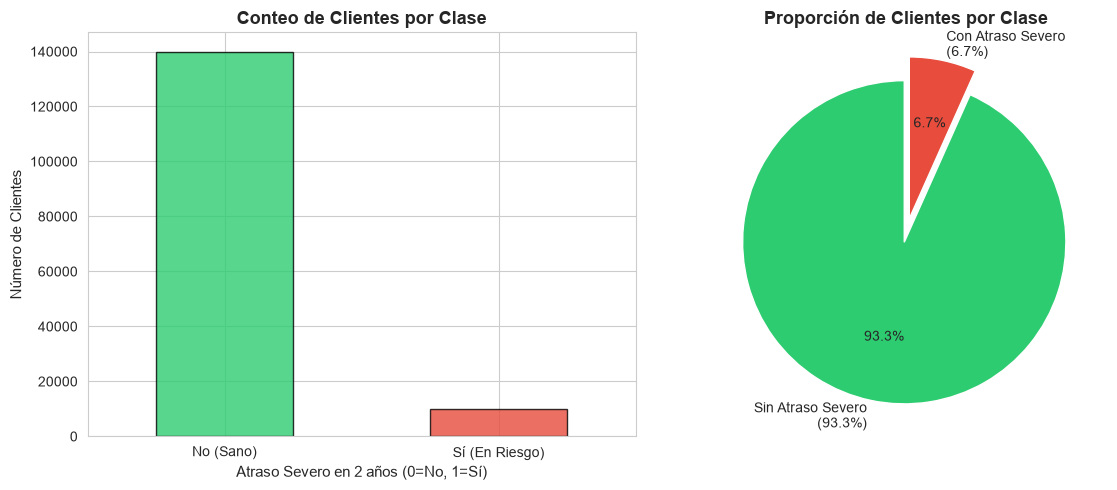

In [6]:
# Análisis de la variable objetivo
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print("Distribución de la Variable Objetivo (SeriousDlqin2yrs):")
print(f"  No (0): {target_counts[0]:,} clientes ({target_pct[0]:.2f}%)")
print(f"  Sí (1): {target_counts[1]:,} clientes ({target_pct[1]:.2f}%)")
print(f"\nDesbalance: El dataset está altamente desbalanceado (proporción 1:{target_counts[0]/target_counts[1]:.1f})")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
colors = ['#2ecc71', '#e74c3c']
target_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='black', alpha=0.8)
ax1.set_title('Conteo de Clientes por Clase', fontsize=13, fontweight='bold')
ax1.set_xlabel('Atraso Severo en 2 años (0=No, 1=Sí)', fontsize=11)
ax1.set_ylabel('Número de Clientes', fontsize=11)
ax1.set_xticklabels(['No (Sano)', 'Sí (En Riesgo)'], rotation=0)

# Gráfico de pastel
labels = ['Sin Atraso Severo\n(93.3%)', 'Con Atraso Severo\n(6.7%)']
ax2.pie(target_counts, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, textprops={'fontsize': 10}, explode=(0.05, 0.1))
ax2.set_title('Proporción de Clientes por Clase', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Análisis Univariado

### 5.1 Análisis de Edad (age)

Exploración de la distribución de edad en el dataset.

Análisis de Edad:
  Media: 52.3 años
  Mediana: 52.0 años
  Mínimo: 0 años
  Máximo: 109 años
  Desv. Estándar: 14.8 años
  Valores únicos: 86


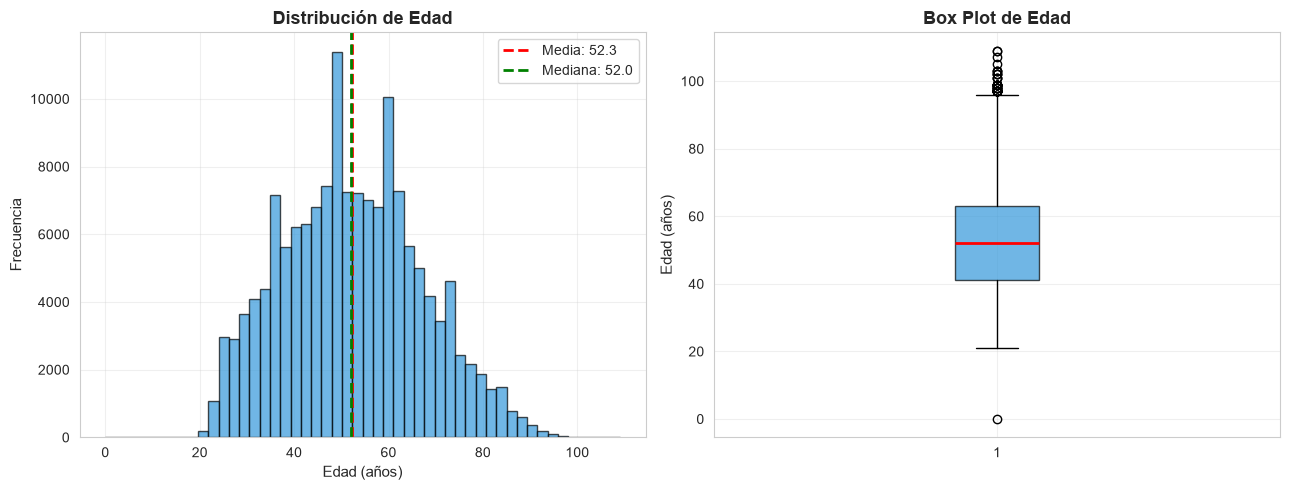

In [7]:
# Análisis de Edad
print("Análisis de Edad:")
print(f"  Media: {df['age'].mean():.1f} años")
print(f"  Mediana: {df['age'].median():.1f} años")
print(f"  Mínimo: {df['age'].min():.0f} años")
print(f"  Máximo: {df['age'].max():.0f} años")
print(f"  Desv. Estándar: {df['age'].std():.1f} años")
print(f"  Valores únicos: {df['age'].nunique()}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(df['age'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["age"].median():.1f}')
axes[0].set_title('Distribución de Edad', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Edad (años)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df['age'], vert=True, patch_artist=True, 
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Edad (años)', fontsize=11)
axes[1].set_title('Box Plot de Edad', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Análisis de Ingreso Mensual (MonthlyIncome)

Distribución del ingreso mensual de los clientes.

Análisis de Ingreso Mensual:
  Media: $6,670
  Mediana: $5,400
  Mínimo: $0
  Máximo: $3,008,750
  Desv. Estándar: $14,385
  Valores cero: 1,634 (1.1%)


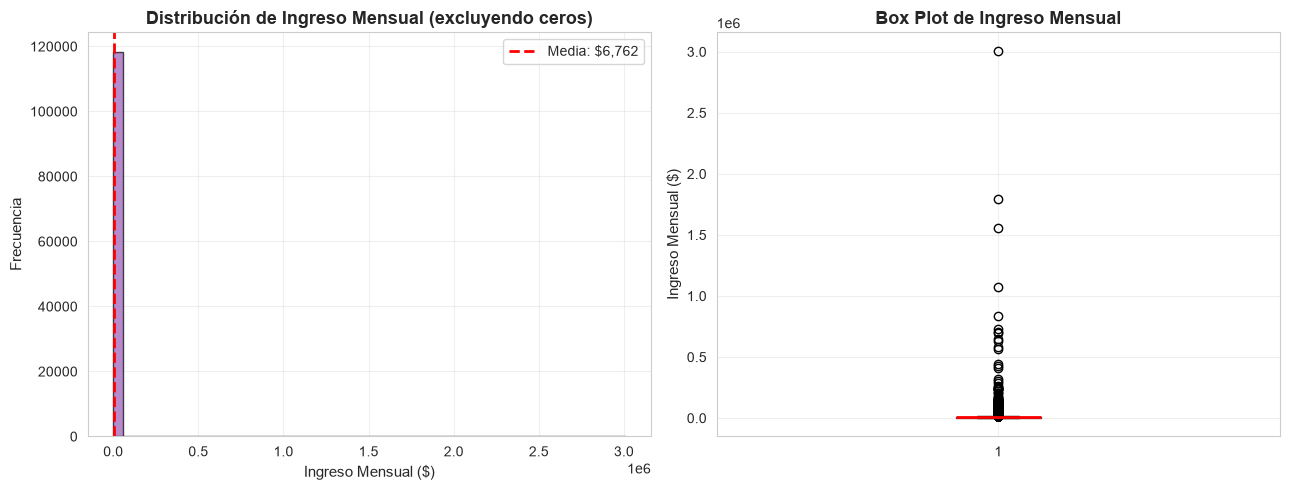

In [8]:
# Análisis de Ingreso Mensual
print("Análisis de Ingreso Mensual:")
print(f"  Media: ${df['MonthlyIncome'].mean():,.0f}")
print(f"  Mediana: ${df['MonthlyIncome'].median():,.0f}")
print(f"  Mínimo: ${df['MonthlyIncome'].min():,.0f}")
print(f"  Máximo: ${df['MonthlyIncome'].max():,.0f}")
print(f"  Desv. Estándar: ${df['MonthlyIncome'].std():,.0f}")
print(f"  Valores cero: {(df['MonthlyIncome'] == 0).sum():,} ({(df['MonthlyIncome'] == 0).sum()/len(df)*100:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma (excluyendo ceros)
income_nonzero = df[df['MonthlyIncome'] > 0]['MonthlyIncome']
axes[0].hist(income_nonzero, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0].axvline(income_nonzero.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${income_nonzero.mean():,.0f}')
axes[0].set_title('Distribución de Ingreso Mensual (excluyendo ceros)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ingreso Mensual ($)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
bp = axes[1].boxplot(income_nonzero, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#9b59b6', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Ingreso Mensual ($)', fontsize=11)
axes[1].set_title('Box Plot de Ingreso Mensual', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Análisis de Ratio de Deuda (DebtRatio)

Relación entre deuda y ingresos de los clientes.

Análisis de Ratio de Deuda:
  Media: 353.0051
  Mediana: 0.3665
  Mínimo: 0.0000
  Máximo: 329664.0000
  Desv. Estándar: 2037.8185
  Valores cero: 4,113


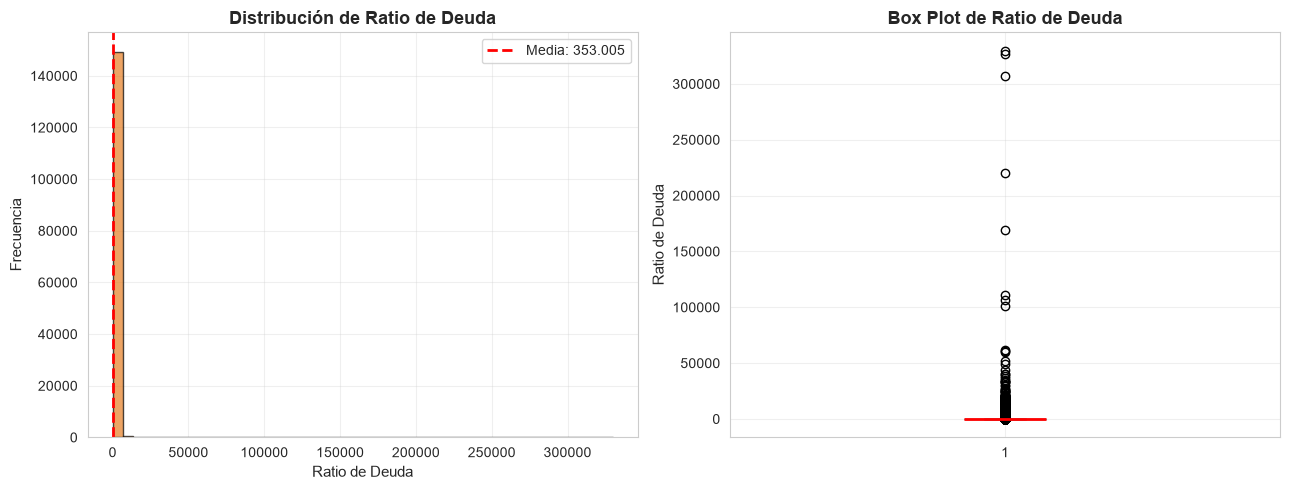

In [9]:
# Análisis de Ratio de Deuda
print("Análisis de Ratio de Deuda:")
print(f"  Media: {df['DebtRatio'].mean():.4f}")
print(f"  Mediana: {df['DebtRatio'].median():.4f}")
print(f"  Mínimo: {df['DebtRatio'].min():.4f}")
print(f"  Máximo: {df['DebtRatio'].max():.4f}")
print(f"  Desv. Estándar: {df['DebtRatio'].std():.4f}")
print(f"  Valores cero: {(df['DebtRatio'] == 0).sum():,}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(df['DebtRatio'], bins=50, color='#e67e22', edgecolor='black', alpha=0.7)
axes[0].axvline(df['DebtRatio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["DebtRatio"].mean():.3f}')
axes[0].set_title('Distribución de Ratio de Deuda', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ratio de Deuda', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df['DebtRatio'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#e67e22', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Ratio de Deuda', fontsize=11)
axes[1].set_title('Box Plot de Ratio de Deuda', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Variables de Historial de Pagos

Exploración de variables relacionadas con atrasos y líneas de crédito.

Análisis de variables de historial de pagos:



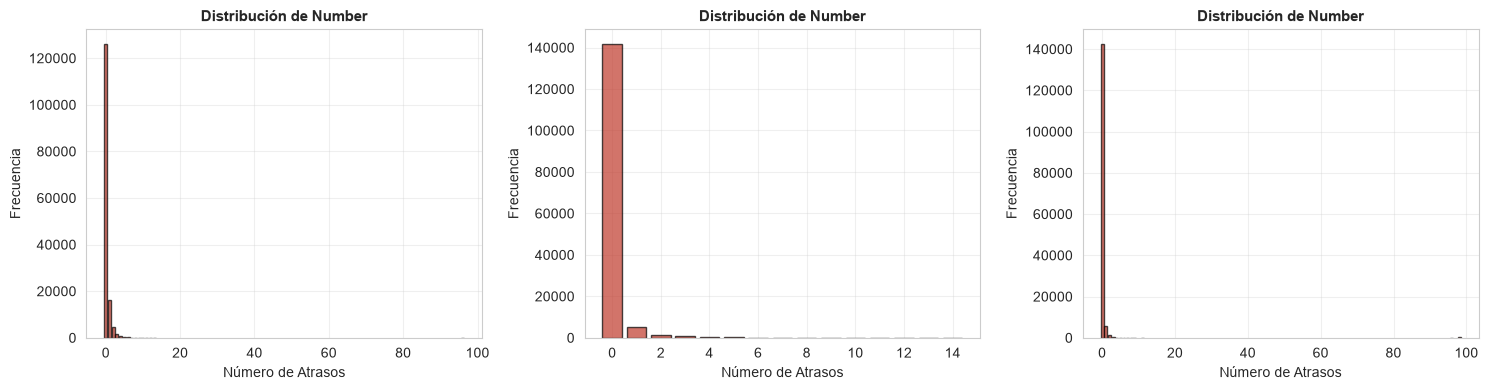

In [10]:
# Variables de historial de pagos
payment_variables = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

print("Análisis de variables de historial de pagos:\n")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, var in enumerate(payment_variables):
    counts = df[var].value_counts().sort_index()
    axes[idx].bar(counts.index[:15], counts.values[:15], color='#c0392b', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {var.split("Of")[0]}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Número de Atrasos', fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 Variables de Líneas de Crédito

Exploración de líneas de crédito abiertas y préstamos hipotecarios.

Análisis de Variables de Líneas de Crédito:

NumberOfOpenCreditLinesAndLoans:
  Media: 8.45
  Mediana: 8
  Máximo: 58
  Desv. Estándar: 5.15

NumberRealEstateLoansOrLines:
  Media: 1.02
  Mediana: 1
  Máximo: 54
  Desv. Estándar: 1.13

NumberOfDependents:
  Media: 0.76
  Mediana: 0
  Máximo: 20
  Desv. Estándar: 1.12



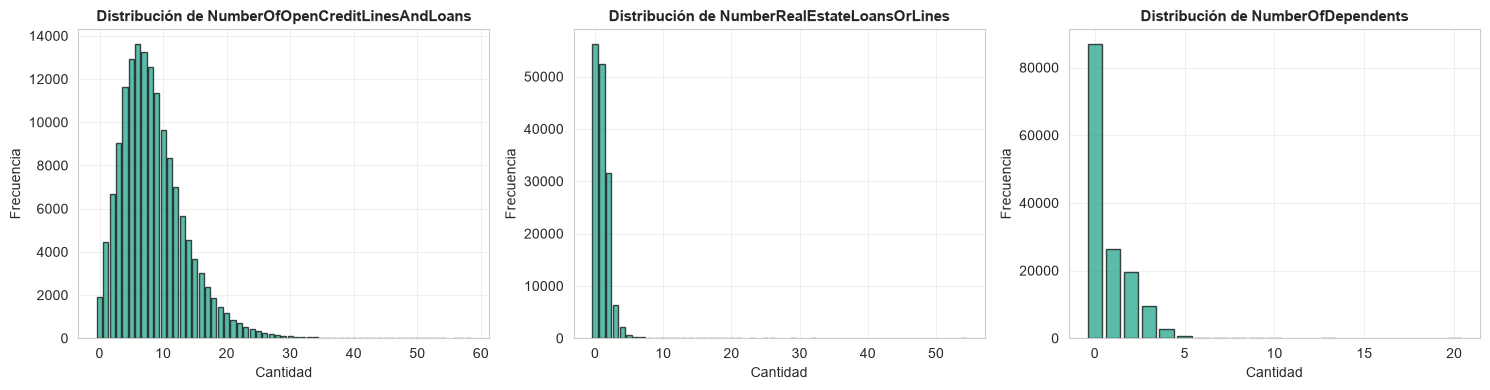

In [11]:
# Variables de líneas de crédito
credit_variables = [
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

print("Análisis de Variables de Líneas de Crédito:\n")
for var in credit_variables:
    print(f"{var}:")
    print(f"  Media: {df[var].mean():.2f}")
    print(f"  Mediana: {df[var].median():.0f}")
    print(f"  Máximo: {df[var].max():.0f}")
    print(f"  Desv. Estándar: {df[var].std():.2f}")
    print()

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, var in enumerate(credit_variables):
    counts = df[var].value_counts().sort_index()
    axes[idx].bar(counts.index, counts.values, color='#16a085', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Cantidad', fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Análisis Bivariado

### 6.1 Relación entre Edad y Variable Objetivo

Estadísticas de Edad por Clase:
                     count   mean    std   min   25%   50%   75%    max
SeriousDlqin2yrs                                                       
0                 139974.0  52.75  14.79   0.0  42.0  52.0  63.0  109.0
1                  10026.0  45.93  12.92  21.0  36.0  45.0  54.0  101.0


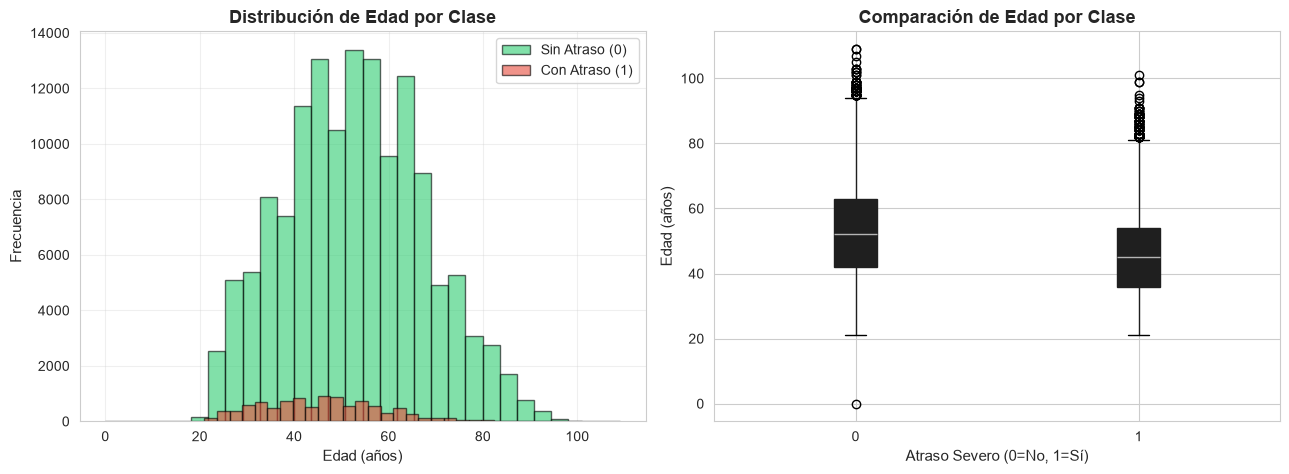

In [12]:
# Relación entre Edad y Variable Objetivo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución por clase
df[df['SeriousDlqin2yrs'] == 0]['age'].hist(bins=30, alpha=0.6, label='Sin Atraso (0)', ax=axes[0], color='#2ecc71', edgecolor='black')
df[df['SeriousDlqin2yrs'] == 1]['age'].hist(bins=30, alpha=0.6, label='Con Atraso (1)', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Distribución de Edad por Clase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Edad (años)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot por clase
df.boxplot(column='age', by='SeriousDlqin2yrs', ax=axes[1], patch_artist=True)
axes[1].set_title('Comparación de Edad por Clase', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Atraso Severo (0=No, 1=Sí)', fontsize=11)
axes[1].set_ylabel('Edad (años)', fontsize=11)
plt.suptitle('')

# Estadísticas
print("Estadísticas de Edad por Clase:")
print(df.groupby('SeriousDlqin2yrs')['age'].describe().round(2))

plt.tight_layout()
plt.show()

### 6.2 Relación entre Ingreso Mensual y Variable Objetivo

Estadísticas de Ingreso Mensual por Clase (excluyendo ceros):
                     count     mean       std  min     25%     50%     75%  \
SeriousDlqin2yrs                                                             
0                 110344.0  6843.73  14896.37  1.0  3500.0  5500.0  8339.0   
1                   8291.0  5675.65   6175.67  1.0  3000.0  4500.0  6840.5   

                        max  
SeriousDlqin2yrs             
0                 3008750.0  
1                  250000.0  


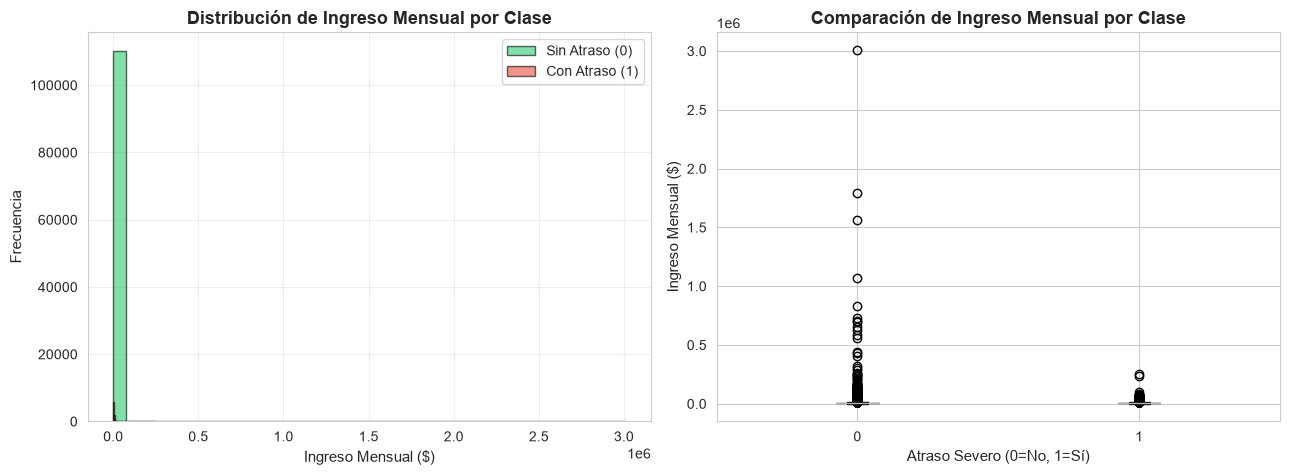

In [13]:
# Relación entre Ingreso Mensual y Variable Objetivo
income_nonzero = df[df['MonthlyIncome'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución por clase (excluyendo ceros)
income_nonzero[income_nonzero['SeriousDlqin2yrs'] == 0]['MonthlyIncome'].hist(bins=40, alpha=0.6, label='Sin Atraso (0)', ax=axes[0], color='#2ecc71', edgecolor='black')
income_nonzero[income_nonzero['SeriousDlqin2yrs'] == 1]['MonthlyIncome'].hist(bins=40, alpha=0.6, label='Con Atraso (1)', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Distribución de Ingreso Mensual por Clase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ingreso Mensual ($)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot por clase
income_nonzero.boxplot(column='MonthlyIncome', by='SeriousDlqin2yrs', ax=axes[1], patch_artist=True)
axes[1].set_title('Comparación de Ingreso Mensual por Clase', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Atraso Severo (0=No, 1=Sí)', fontsize=11)
axes[1].set_ylabel('Ingreso Mensual ($)', fontsize=11)
plt.suptitle('')

# Estadísticas
print("Estadísticas de Ingreso Mensual por Clase (excluyendo ceros):")
print(income_nonzero.groupby('SeriousDlqin2yrs')['MonthlyIncome'].describe().round(2))

plt.tight_layout()
plt.show()

### 6.3 Relación entre Ratio de Deuda y Variable Objetivo

Estadísticas de Ratio de Deuda por Clase:
                     count      mean        std  min     25%     50%     75%  \
SeriousDlqin2yrs                                                               
0                 139974.0  357.1512  2083.2821  0.0  0.1737  0.3627  0.8656   
1                  10026.0  295.1211  1238.3603  0.0  0.1940  0.4282  0.8924   

                       max  
SeriousDlqin2yrs            
0                 329664.0  
1                  38793.0  


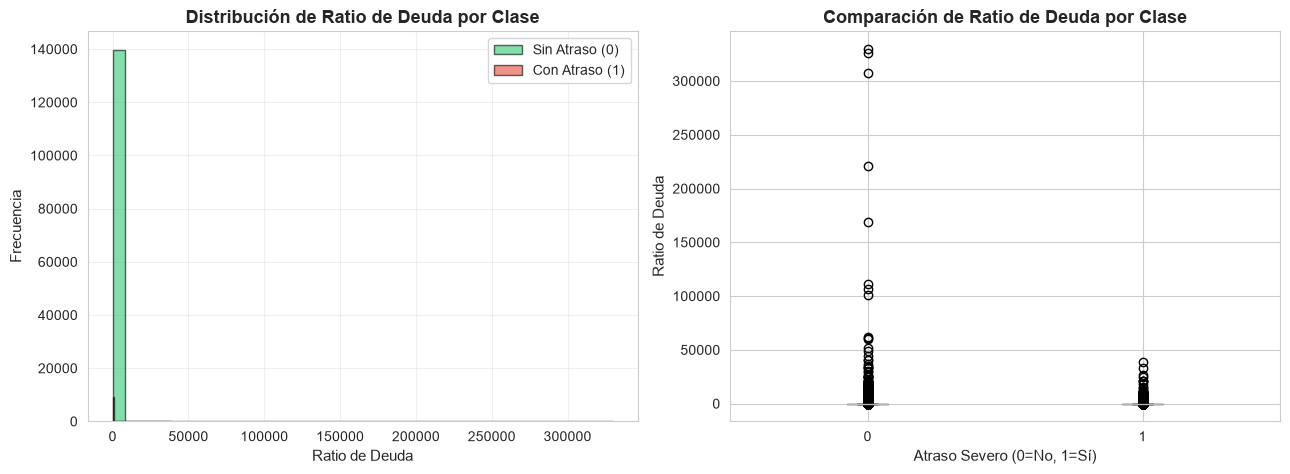

In [14]:
# Relación entre Ratio de Deuda y Variable Objetivo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución por clase
df[df['SeriousDlqin2yrs'] == 0]['DebtRatio'].hist(bins=40, alpha=0.6, label='Sin Atraso (0)', ax=axes[0], color='#2ecc71', edgecolor='black')
df[df['SeriousDlqin2yrs'] == 1]['DebtRatio'].hist(bins=40, alpha=0.6, label='Con Atraso (1)', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Distribución de Ratio de Deuda por Clase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ratio de Deuda', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot por clase
df.boxplot(column='DebtRatio', by='SeriousDlqin2yrs', ax=axes[1], patch_artist=True)
axes[1].set_title('Comparación de Ratio de Deuda por Clase', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Atraso Severo (0=No, 1=Sí)', fontsize=11)
axes[1].set_ylabel('Ratio de Deuda', fontsize=11)
plt.suptitle('')

# Estadísticas
print("Estadísticas de Ratio de Deuda por Clase:")
print(df.groupby('SeriousDlqin2yrs')['DebtRatio'].describe().round(4))

plt.tight_layout()
plt.show()

### 6.4 Tasa de Atraso Grave por Número de Atrasos Previos

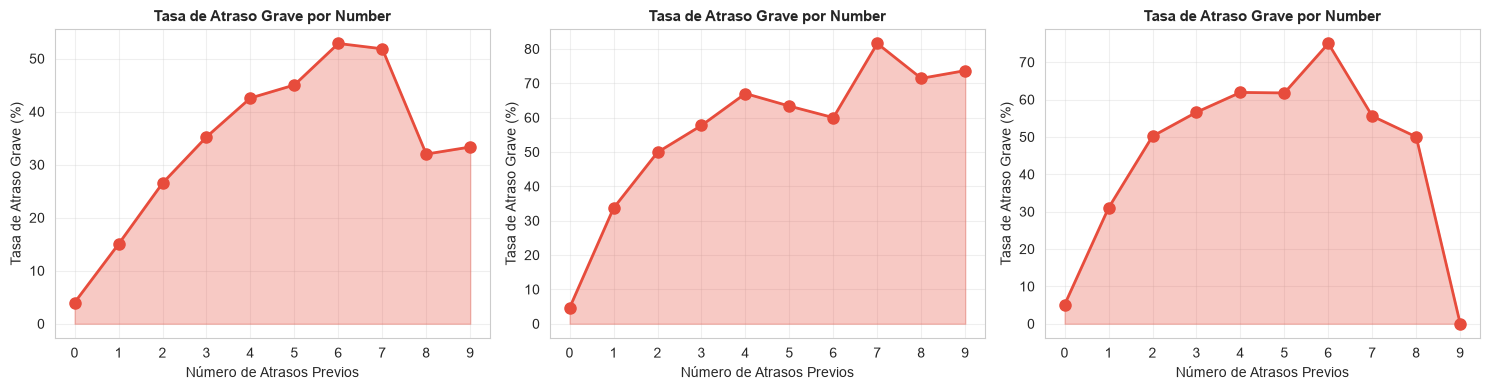

Observación: El histórico de atrasos es un predictor fuerte de atrasos graves futuros.


In [15]:
# Tasa de atraso grave por histórico de atrasos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

payment_vars = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for idx, var in enumerate(payment_vars):
    # Calcular tasa de atraso grave por grupo
    delinquency_rate = df.groupby(var)['SeriousDlqin2yrs'].agg(['sum', 'count'])
    delinquency_rate['rate'] = (delinquency_rate['sum'] / delinquency_rate['count'] * 100)
    
    # Mostrar hasta 10 categorías para claridad
    delinquency_rate = delinquency_rate.head(10)
    
    axes[idx].plot(delinquency_rate.index, delinquency_rate['rate'], marker='o', linewidth=2, markersize=8, color='#e74c3c')
    axes[idx].fill_between(delinquency_rate.index, delinquency_rate['rate'], alpha=0.3, color='#e74c3c')
    axes[idx].set_title(f'Tasa de Atraso Grave por {var.split("Of")[0]}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Número de Atrasos Previos', fontsize=10)
    axes[idx].set_ylabel('Tasa de Atraso Grave (%)', fontsize=10)
    axes[idx].grid(alpha=0.3)
    axes[idx].set_xticks(delinquency_rate.index)

plt.tight_layout()
plt.show()

print("Observación: El histórico de atrasos es un predictor fuerte de atrasos graves futuros.")

## 7. Análisis de Correlaciones

### 7.1 Matriz de Correlación

Correlación de Variables con la Variable Objetivo (SeriousDlqin2yrs):
SeriousDlqin2yrs                        1.0000
NumberOfTime30-59DaysPastDueNotWorse    0.1256
NumberOfTimes90DaysLate                 0.1172
NumberOfTime60-89DaysPastDueNotWorse    0.1023
NumberOfDependents                      0.0460
RevolvingUtilizationOfUnsecuredLines   -0.0018
NumberRealEstateLoansOrLines           -0.0070
DebtRatio                              -0.0076
MonthlyIncome                          -0.0197
NumberOfOpenCreditLinesAndLoans        -0.0297
age                                    -0.1154
Name: SeriousDlqin2yrs, dtype: float64


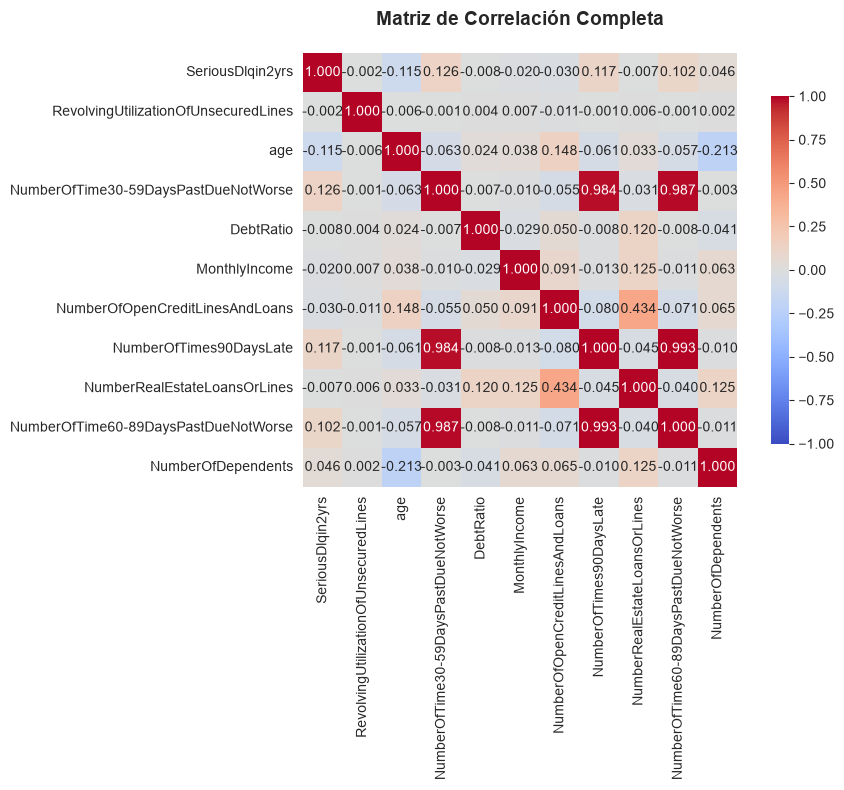

In [16]:
# Matriz de correlación
correlation_matrix = df.corr()

# Mostrar correlaciones con la variable objetivo
print("Correlación de Variables con la Variable Objetivo (SeriousDlqin2yrs):")
target_corr = correlation_matrix['SeriousDlqin2yrs'].sort_values(ascending=False)
print(target_corr.round(4))

# Visualización de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
plt.title('Matriz de Correlación Completa', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 7.2 Correlaciones Más Relevantes con la Variable Objetivo

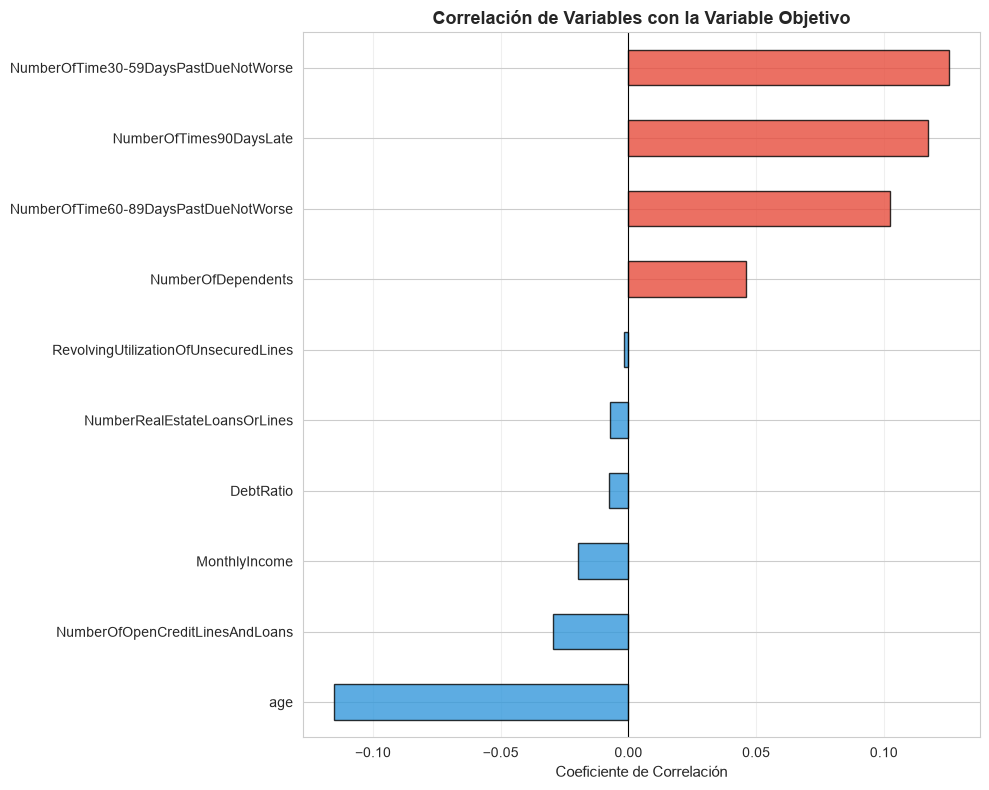


💡 Hallazgo Clave:
Las variables más correlacionadas con atrasos graves son:
  1. NumberOfTime30-59DaysPastDueNotWorse: 0.1256
  2. NumberOfTimes90DaysLate: 0.1172
  3. NumberOfTime60-89DaysPastDueNotWorse: 0.1023


In [17]:
# Gráfico de correlaciones con la variable objetivo
target_corr_sorted = target_corr.drop('SeriousDlqin2yrs').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr_sorted.values]
target_corr_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Correlación de Variables con la Variable Objetivo', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlación', fontsize=11)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n💡 Hallazgo Clave:")
print(f"Las variables más correlacionadas con atrasos graves son:")
print(f"  1. {target_corr_sorted.index[-1]}: {target_corr_sorted.values[-1]:.4f}")
print(f"  2. {target_corr_sorted.index[-2]}: {target_corr_sorted.values[-2]:.4f}")
print(f"  3. {target_corr_sorted.index[-3]}: {target_corr_sorted.values[-3]:.4f}")

## 8. Detección de Valores Atípicos

### 8.1 Outliers por Variables Clave

Análisis de Valores Atípicos (Outliers) usando IQR:

MonthlyIncome: 4,879 outliers (3.25%)
DebtRatio: 31,311 outliers (20.87%)
age: 46 outliers (0.03%)
NumberOfOpenCreditLinesAndLoans: 3,980 outliers (2.65%)


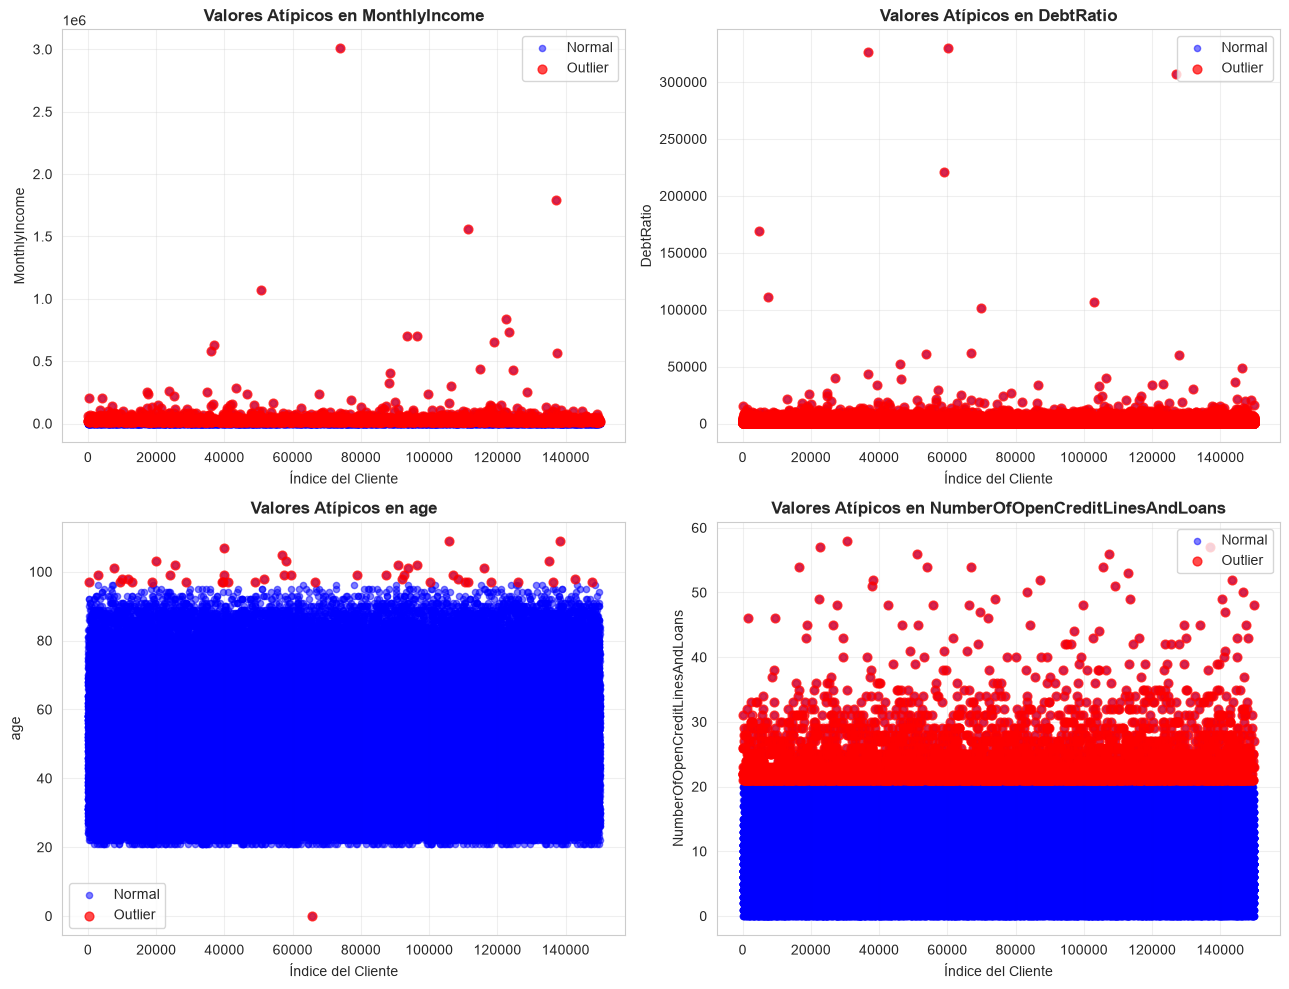

In [18]:
# Función para detectar outliers usando IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Detectar outliers en variables clave
key_vars = ['MonthlyIncome', 'DebtRatio', 'age', 'NumberOfOpenCreditLinesAndLoans']

print("Análisis de Valores Atípicos (Outliers) usando IQR:\n")
outlier_summary = []
for var in key_vars:
    outliers = detect_outliers_iqr(df, var)
    pct = outliers.sum() / len(df) * 100
    print(f"{var}: {outliers.sum():,} outliers ({pct:.2f}%)")
    outlier_summary.append({'Variable': var, 'Outliers': outliers.sum(), 'Porcentaje': pct})

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for idx, var in enumerate(key_vars):
    outliers = detect_outliers_iqr(df, var)
    
    # Scatter plot con outliers destacados
    axes[idx].scatter(range(len(df)), df[var], c='blue', alpha=0.5, label='Normal', s=20)
    axes[idx].scatter(df[outliers].index, df[outliers][var], c='red', alpha=0.7, label='Outlier', s=40)
    
    axes[idx].set_title(f'Valores Atípicos en {var}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Índice del Cliente', fontsize=10)
    axes[idx].set_ylabel(var, fontsize=10)
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Resumen de Hallazgos y Conclusiones

### 9.1 Hallazgos Principales

In [19]:
print("="*80)
print("RESUMEN DE HALLAZGOS PRINCIPALES".center(80))
print("="*80)

print("\n1. DESBALANCE DE CLASES:")
print(f"   • El dataset está altamente desbalanceado: {target_pct[0]:.1f}% sin atraso vs {target_pct[1]:.1f}% con atraso")
print(f"   • Ratio de desbalance: 1 a {target_counts[0]/target_counts[1]:.1f}")
print("   → Implicación: Necesitará estrategias de balanceo en el modelado")

print("\n2. DEMOGRAFÍA:")
print(f"   • Edad promedio: {df['age'].mean():.1f} años (rango: {df['age'].min():.0f}-{df['age'].max():.0f})")
print(f"   • Edad mediana: {df['age'].median():.1f} años")
print(f"   • Distribución de edad es relativamente uniforme")

print("\n3. INGRESOS:")
print(f"   • {(df['MonthlyIncome'] == 0).sum():,} clientes ({(df['MonthlyIncome'] == 0).sum()/len(df)*100:.1f}%) sin ingreso reportado")
print(f"   • Ingreso promedio (no-cero): ${df[df['MonthlyIncome'] > 0]['MonthlyIncome'].mean():,.0f}")
print(f"   • Clientes sin atrasos tienen ingresos ligeramente mayores")

print("\n4. DEUDA:")
print(f"   • Ratio de deuda promedio: {df['DebtRatio'].mean():.3f}")
print(f"   • Rango: {df['DebtRatio'].min():.4f} a {df['DebtRatio'].max():.4f}")
print(f"   • Clientes con atrasos graves tienen mayor ratio de deuda")

print("\n5. HISTORIAL DE PAGOS:")
print(f"   • {(df['NumberOfTimes90DaysLate'] > 0).sum():,} clientes ({(df['NumberOfTimes90DaysLate'] > 0).sum()/len(df)*100:.1f}%) tienen atrasos de 90+ días")
print(f"   • El historial de atrasos es el predictor más fuerte de atrasos graves futuros")
print(f"   • Correlación con variable objetivo: {correlation_matrix.loc['NumberOfTimes90DaysLate', 'SeriousDlqin2yrs']:.4f}")

print("\n6. LÍNEAS DE CRÉDITO:")
print(f"   • Promedio de líneas de crédito abiertas: {df['NumberOfOpenCreditLinesAndLoans'].mean():.1f}")
print(f"   • Promedio de préstamos hipotecarios: {df['NumberRealEstateLoansOrLines'].mean():.1f}")
print(f"   • {(df['NumberOfDependents'] > 0).sum():,} clientes ({(df['NumberOfDependents'] > 0).sum()/len(df)*100:.1f}%) tienen dependientes reportados")

print("\n7. VALORES FALTANTES:")
print(f"   • Ingreso mensual: {df['MonthlyIncome'].isnull().sum():,} valores faltantes")
print(f"   • Dependientes: {df['NumberOfDependents'].isnull().sum():,} valores faltantes")
print(f"   • Otras variables: Sin valores faltantes reportados")

print("\n" + "="*80)
print("RECOMENDACIONES PARA EL MODELADO".center(80))
print("="*80)

print("\n✓ Estrategias recomendadas:")
print("  1. Usar técnicas de balanceo (SMOTE, class_weight en modelos)")
print("  2. Imputar ingresos faltantes (estrategia: media, mediana o modelos predictivos)")
print("  3. Crear features de interacción: Ingreso * DebtRatio, Edad * Atrasos")
print("  4. Detectar y tratar outliers antes del modelado")
print("  5. Usar métricas apropiadas: AUC-ROC, Precision-Recall, F1 (no accuracy)")
print("  6. El histórico de atrasos es el predictor clave, proteger en validación")
print("\n" + "="*80)

                        RESUMEN DE HALLAZGOS PRINCIPALES                        

1. DESBALANCE DE CLASES:
   • El dataset está altamente desbalanceado: 93.3% sin atraso vs 6.7% con atraso
   • Ratio de desbalance: 1 a 14.0
   → Implicación: Necesitará estrategias de balanceo en el modelado

2. DEMOGRAFÍA:
   • Edad promedio: 52.3 años (rango: 0-109)
   • Edad mediana: 52.0 años
   • Distribución de edad es relativamente uniforme

3. INGRESOS:
   • 1,634 clientes (1.1%) sin ingreso reportado
   • Ingreso promedio (no-cero): $6,762
   • Clientes sin atrasos tienen ingresos ligeramente mayores

4. DEUDA:
   • Ratio de deuda promedio: 353.005
   • Rango: 0.0000 a 329664.0000
   • Clientes con atrasos graves tienen mayor ratio de deuda

5. HISTORIAL DE PAGOS:
   • 8,338 clientes (5.6%) tienen atrasos de 90+ días
   • El historial de atrasos es el predictor más fuerte de atrasos graves futuros
   • Correlación con variable objetivo: 0.1172

6. LÍNEAS DE CRÉDITO:
   • Promedio de líneas de c